[*] Loading Acoustic Intelligence from: acoustic_features.csv
[*] Generating Tactical Map for Profile at Lat: -4.006523333333333, Lon: 76.29734


KeyError: 'is_thermocline'

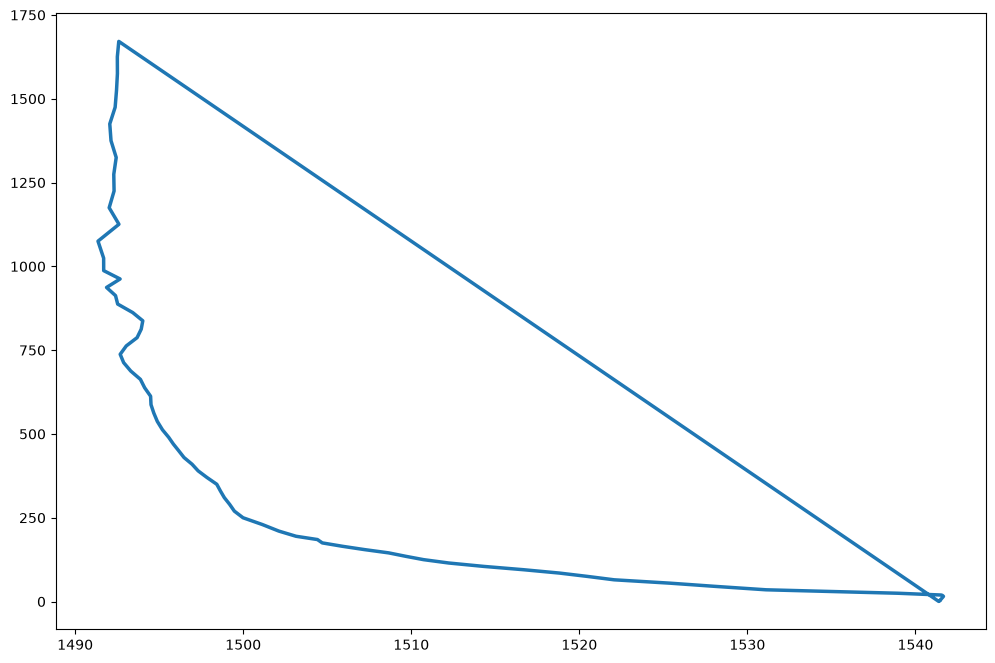

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Resolve Paths and Load the Data
BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data" / "processed" / "acoustic_features.csv"

print(f"[*] Loading Acoustic Intelligence from: {DATA_PATH.name}")
df = pd.read_csv(DATA_PATH)

# 2. Extract a single profile to visualize
# We group by Lat/Lon and grab the first ARGO float in the dataset
grouped = list(df.groupby(['latitude', 'longitude']))
if not grouped:
    raise ValueError("No data found! Ensure Engineer 3's pipeline ran successfully.")

(lat, lon), profile_data = grouped[0]
print(f"[*] Generating Tactical Map for Profile at Lat: {lat}, Lon: {lon}")

# 3. Initialize the Plot
plt.figure(figsize=(12, 8))

# Plot the baseline Sound Velocity Profile (SVP)
plt.plot(
    profile_data['sound_speed'], 
    profile_data['pressure'], 
    label='Sound Velocity Profile (c)', 
    color='#1f77b4', 
    linewidth=2.5,
    zorder=1
)

# 4. Overlay Tactical Zones (Thermoclines)
if 'is_thermocline' in profile_data.columns:
    thermoclines = profile_data[profile_data['is_thermocline']].copy()
    if not thermoclines.empty:
        plt.scatter(
            thermoclines['sound_speed'], 
            thermoclines['pressure'], 
            color='#ff7f0e', 
            s=60, 
            label='Thermocline (Steep Temperature Gradient)', 
            zorder=2
        )
else:
    print('[!] No thermocline flag column found; skipping thermocline overlay.')

# 5. Overlay Tactical Zones (Deep Sound Channels)
if 'is_sound_channel' in profile_data.columns:
    sound_channels = profile_data[profile_data['is_sound_channel']].copy()
    if not sound_channels.empty:
        plt.scatter(
            sound_channels['sound_speed'], 
            sound_channels['pressure'], 
            color='#d62728', 
            s=200, 
            marker='*', 
            label='Deep Sound Channel (Shadow Zone Boundary)', 
            zorder=3
        )
else:
    print('[!] No sound channel flag column found; skipping sound channel overlay.')

# 6. Format the Visuals for Research-Grade Output
plt.gca().invert_yaxis() # CRITICAL: Ocean surface (0m) must be at the top
plt.title(f"AcousticGuard-OS: Tactical Sound Velocity Profile\nLocation: {lat}°N, {lon}°E", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Sound Speed (m/s)", fontsize=12, fontweight='bold')
plt.ylabel("Depth / Pressure (dbar)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)

# 7. Save and Render
OUTPUT_DIR = BASE_DIR / "data" / "processed" # Temporarily saving here for the MVP
plt.savefig(OUTPUT_DIR / "tactical_svp_map.png", dpi=300, bbox_inches='tight')
plt.show()

print("[+] Success! Visualization rendered and saved.")
